In [1]:
import numpy as np
from astropy.io import fits
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib
%matplotlib widget

def load_ims(datadir, inds):
    fns = np.sort(glob.glob(datadir+'*cube.fits'))
    # loading the data
    # NOTE. nothing with refpixels
    ims = np.array([fits.getdata(fn)[inds] for fn in fns])
    reset = np.mean(ims[:,0,:,:],axis=0)
    #ims = ims[:,1:,:,:] - reset
    ims_flat = ims.copy()
    n_exp, n_read, ny, nx = ims.shape
    n_pix = ny*nx
    ims_flat.shape = (n_exp, n_read, n_pix)
    return ims_flat, ims, reset

# Load data and run PTC


Optimizer status 2: `ftol` termination condition is satisfied.
PTC fit results
  Gain       : 3.460 e⁻/DN
  Read noise : 0.000 DN  (0.000 e⁻)


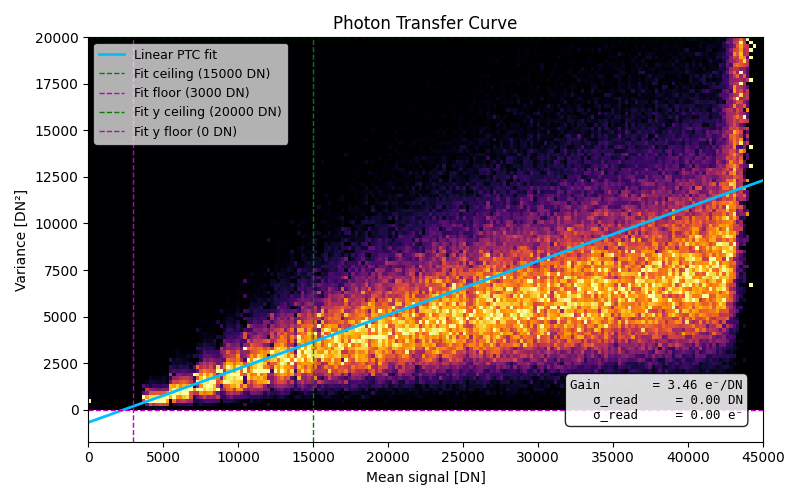

Figure saved to ./plots_saturated_flats_UTR/


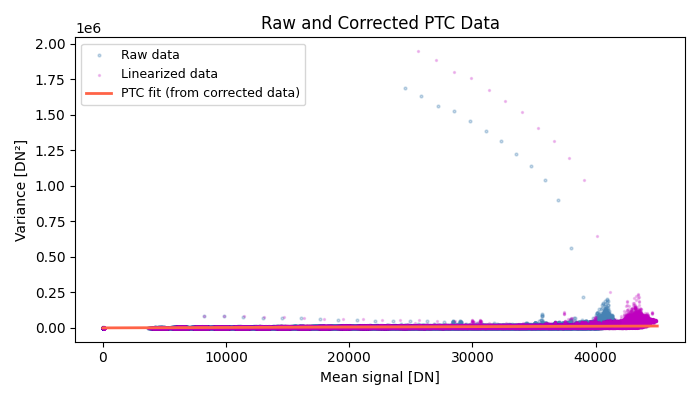

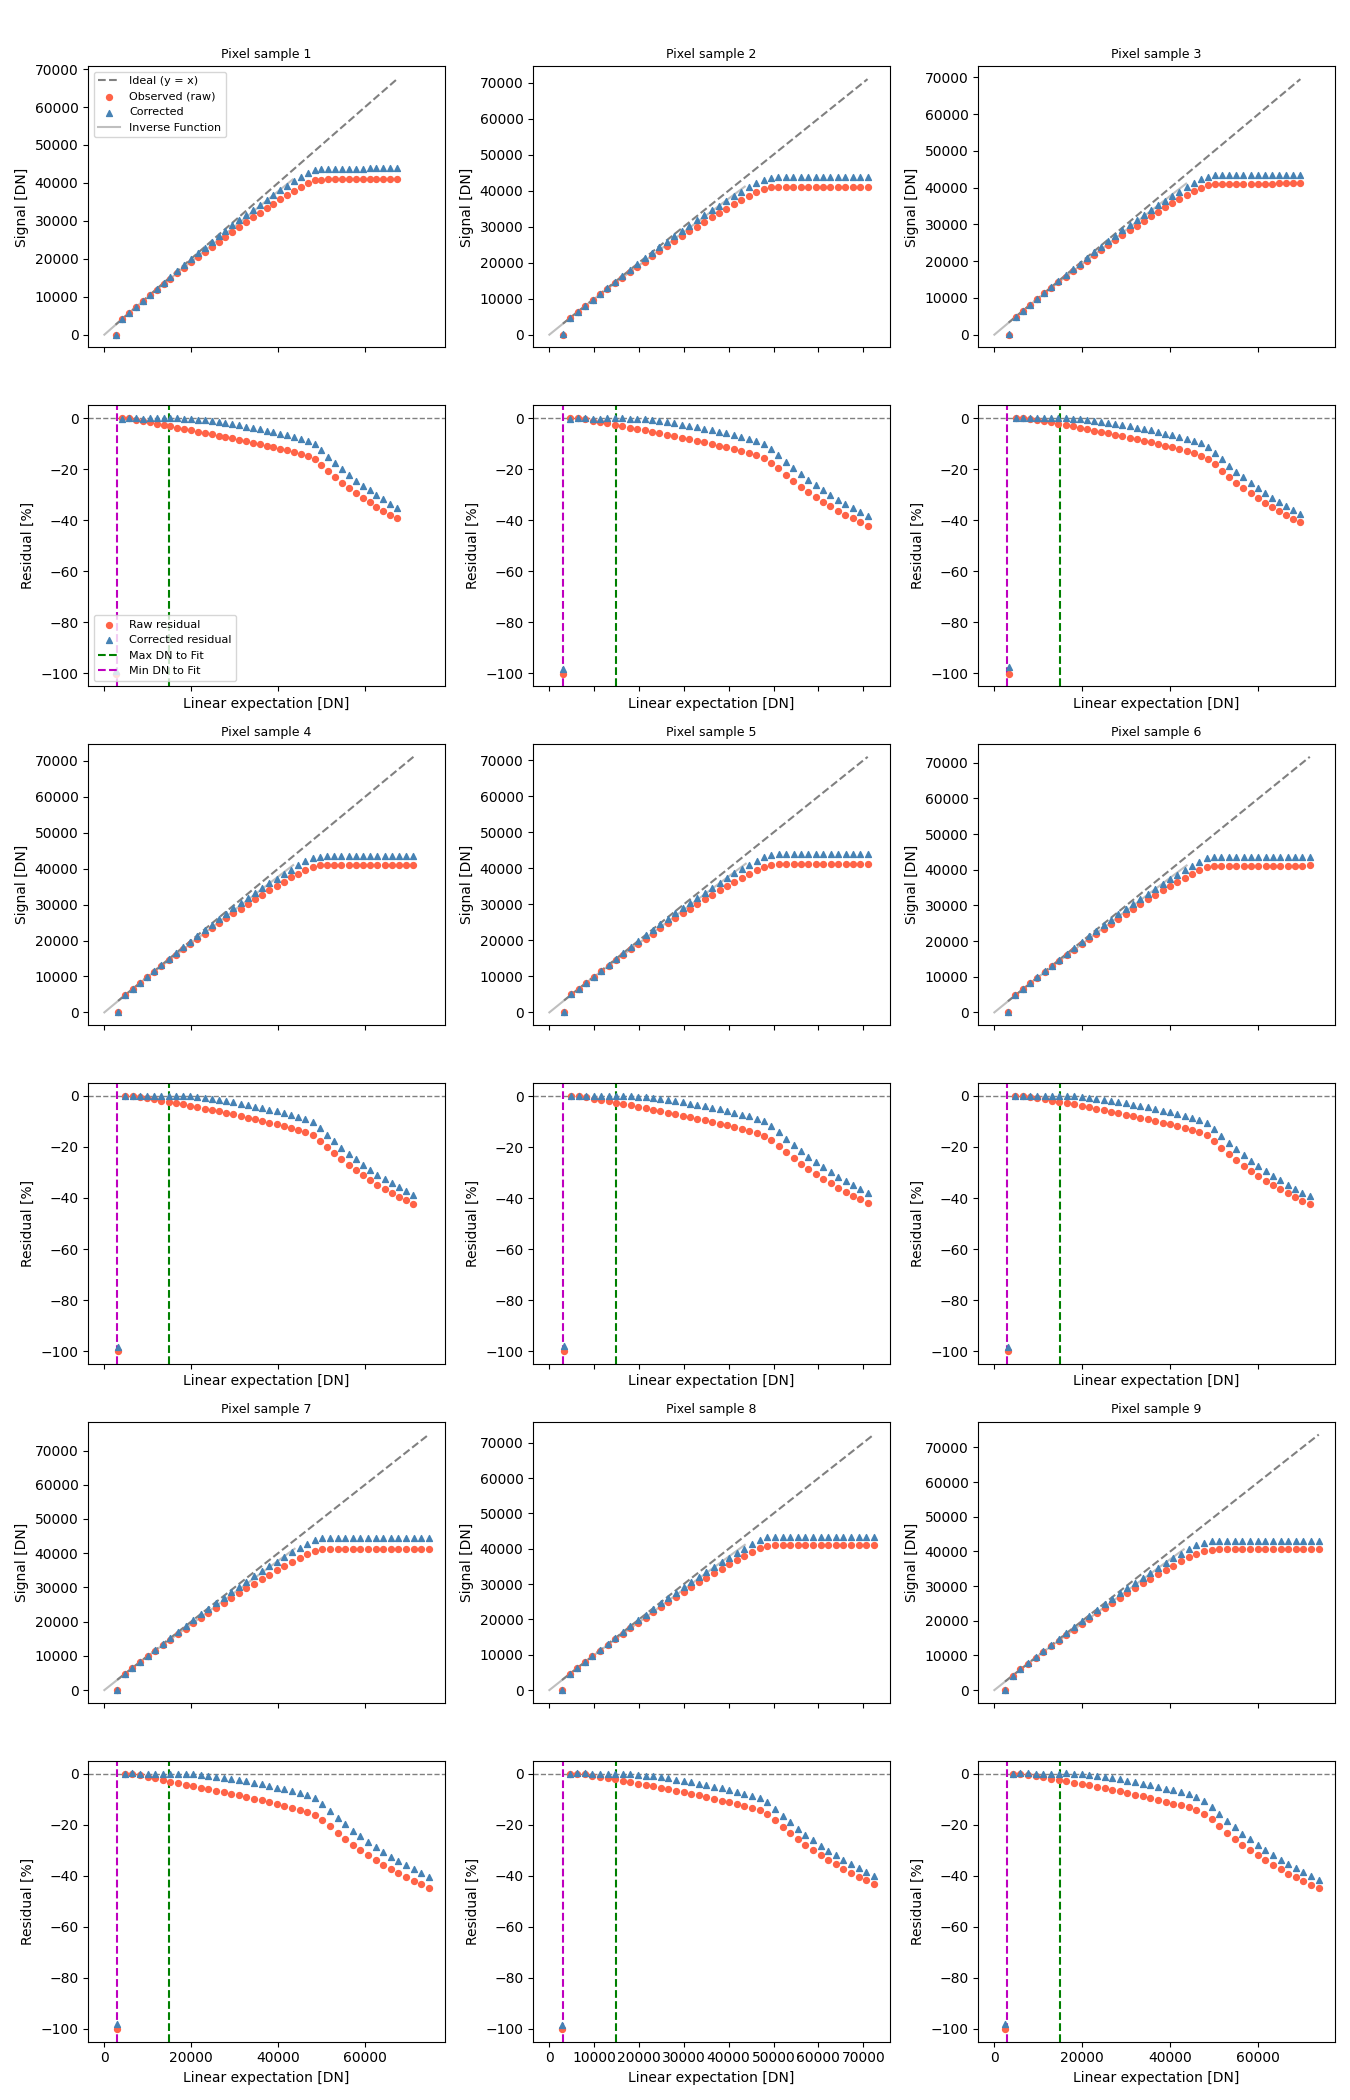

Figure saved to ./plots_saturated_flats_UTR/


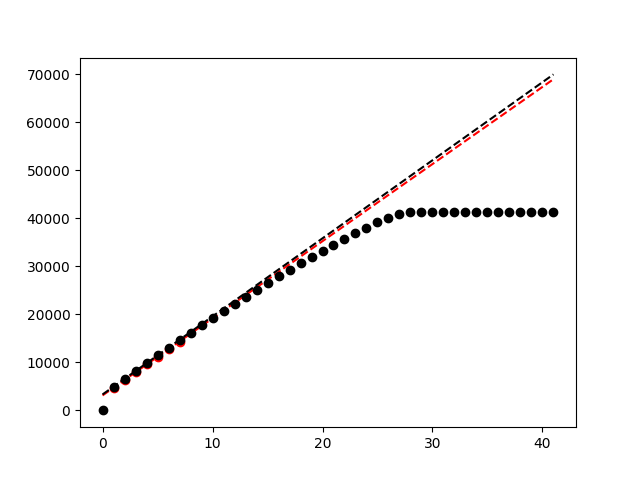

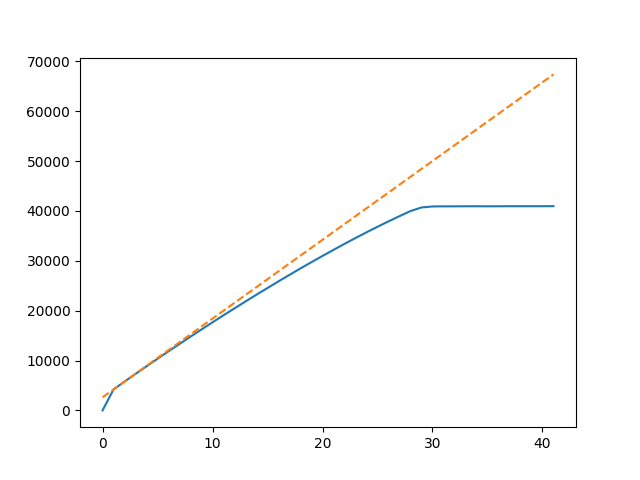

In [11]:
from ptc_gain import compute_ptc

# Load DATA
DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260226/'
data_dir = 'utr_10reads/'
DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260303/'
data_dir = 'saturated_flats_UTR/'
#DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260227/'
#data_dir = 'utr_10/'
min,max = 800, 900 #100,150
inds     = np.s_[:,min:max,min:max]
ims,ims_notflat,reset = load_ims(DATA_FOLDER + data_dir, inds)

save_path = f'./plots_{data_dir}'
# Run PTC
result = compute_ptc(ims, 
                     correct_nonlinearity=True,
                     poly_degree=2,
                     fit_min_mean_dn= 3000,
                     fit_min_var_dn2= 0,
                     fit_max_mean_dn=15_000, 
                     fit_max_var_dn2=20_000,
                     plot_max_mean_dn=45_000,
                     plot_max_var_dn2=None,
                     save_path=save_path)


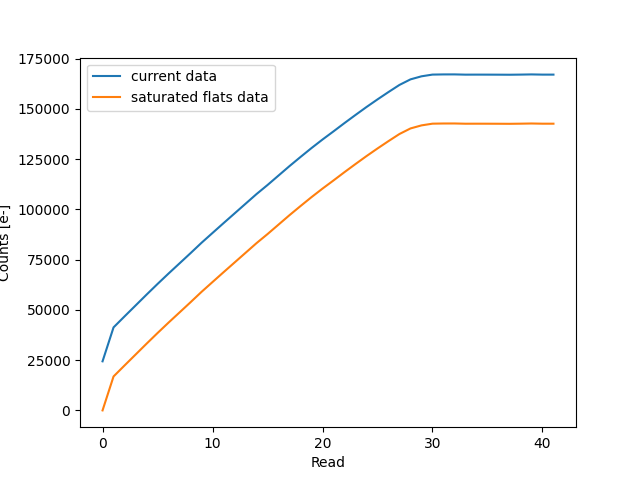

In [ ]:

# plot ramp in electrons
plt.figure()
plt.plot(ims_notflat[0,:,10,10] * result.gain,label='current data')

# load saturated files
DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260303/'
data_dir    = 'saturated_flats_UTR/'
min,max = 800,1200
inds     = np.s_[:,min:max,min:max]
_,ims_notflat_sat,_ = load_ims(DATA_FOLDER + data_dir, inds)

plt.plot((ims_notflat_sat[0,:,10,10] -ims_notflat_sat[0,0,10,10]) * result.gain,label='saturated flats data')
plt.xlabel('Read')
plt.ylabel('Counts [e-]')
plt.legend()
plt.show()





In [ ]:
# Try my own
n_exp, n_read, ny, nx = ims_notflat.shape
means = np.nanmean(ims_notflat[:, :, 10,12],axis=0)
vars = np.nanvar(ims_notflat[:, :, 10,12],axis=0)
print('reads', n_read)


reads 10


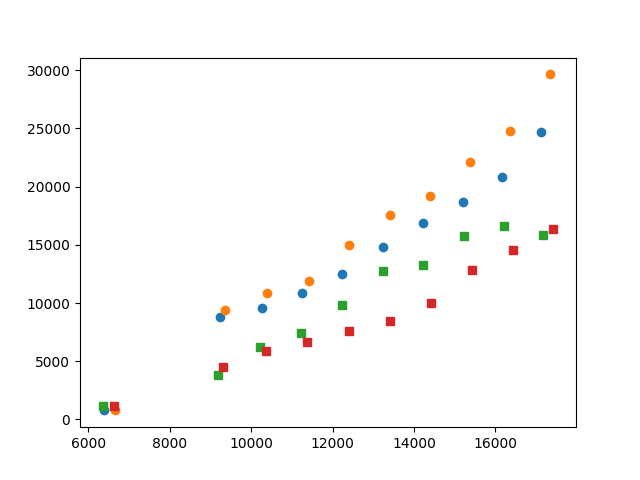

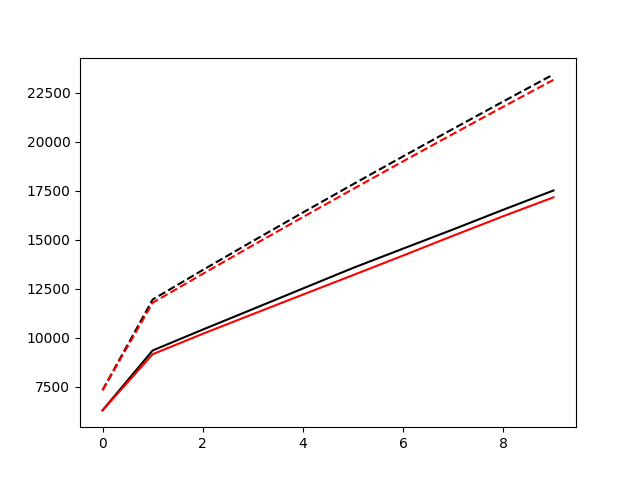

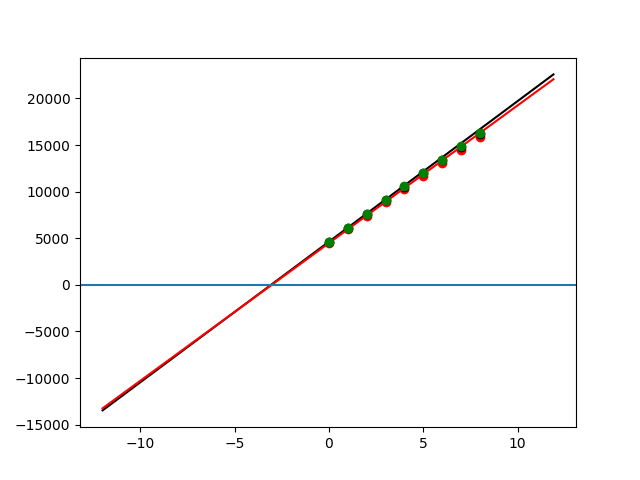

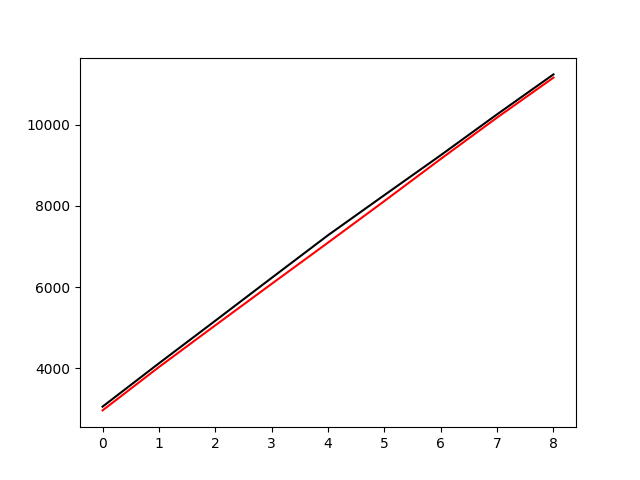

In [ ]:
DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260226/'
data_dir = 'utr_10reads/'
min,max = 100, 150 #100,150
inds     = np.s_[:,min:max,min:max]
ims,ims_notflat,reset = load_ims(DATA_FOLDER + data_dir, inds)

plt.figure()
for i in np.arange(2):
    n_exp, n_read, ny, nx = ims_notflat.shape
    means = np.nanmean(ims[:, :, i],axis=0)
    vars = np.nanvar(ims[:, :, i],axis=0)
    plt.plot(means,vars,'o')


#DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260303/'
#data_dir = 'saturated_flats_UTR/'
DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260227/'
data_dir = 'utr_10/'
min,max = 100, 1024 #100,150
inds     = np.s_[:,min:max,min:max]
ims,ims_notflat,reset = load_ims(DATA_FOLDER + data_dir, inds)

for i in np.arange(2):
    n_exp, n_read, ny, nx = ims_notflat.shape
    means = np.nanmean(ims[:, :, i],axis=0)
    vars = np.nanvar(ims[:, :, i],axis=0)
    plt.plot(means,vars,'s')

plt.figure()
for i in np.arange(1):
    plt.plot(ims[0,:,i],c='k')

plt.plot(np.mean(ims[0,:,:],axis=1),'k--')
slope1 = np.mean(ims[0,:,:],axis=1)
slope1 -= slope1[0]
slope1 = slope1[1:]

for i in np.arange(1):
    plt.plot(ims[1,:,i],c='r')

plt.plot(np.mean(ims[1,:,:],axis=1),'r--')
slope2 = np.mean(ims[1,:,:],axis=1)
slope2 -= slope2[0]
slope2 = slope2[1:]

plt.figure()
plt.plot(slope2,'ro')
plt.plot(slope1,'ko')
# fit each average image slope with line - goal to see where each crosses 0
x = np.arange(len(slope1))
pcoeff1 = np.polyfit(x[0:2], slope1[0:2],deg=1)
pcoeff2 = np.polyfit(x[0:2], slope2[0:2],deg=1)


xnew = np.arange(-12,12,0.1)
plt.plot(xnew, xnew * pcoeff1[0] + pcoeff1[1],'k')
plt.plot(xnew, xnew * pcoeff2[0] + pcoeff2[1],'r')
plt.axhline(0)

# adjust slope 2 to match as test
fit1 = x * pcoeff1[0] + pcoeff1[1]
fit2 = x * pcoeff2[0] + pcoeff2[1]
plt.plot(x, slope2 * fit1/fit2,'go')




In [1]:
# now plot several pixels 
plt.figure()
plt.plot( fit1/fit2 * (ims[1,1:,i] - ims[1,0,i]),'r--')
plt.plot((ims[1,1:,i] - ims[1,0,i]),c='r')
plt.plot(ims[0,1:,i] - ims[0,0,i],c='k')


NameError: name 'plt' is not defined

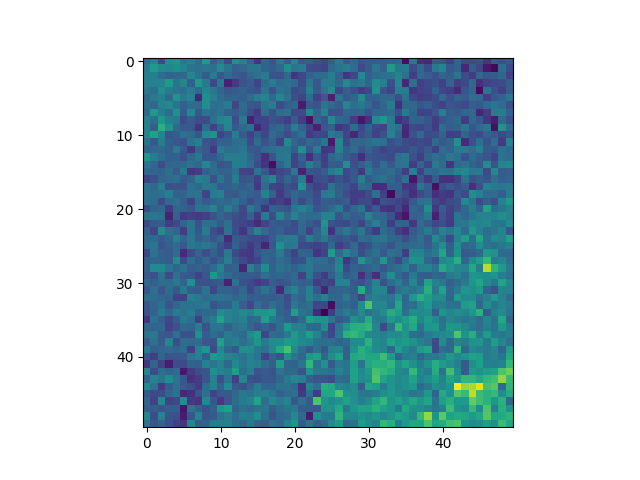

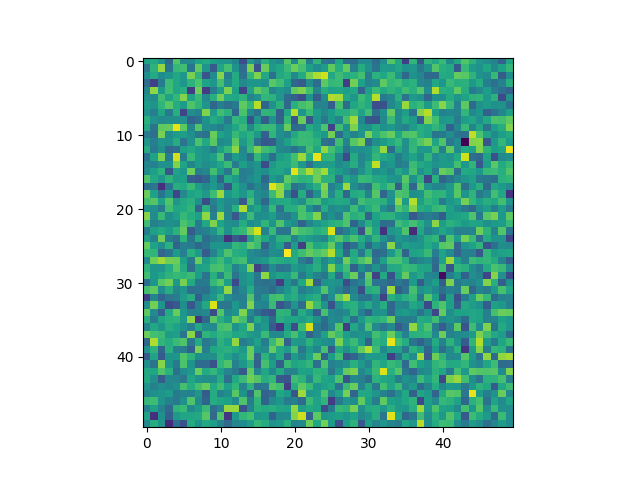

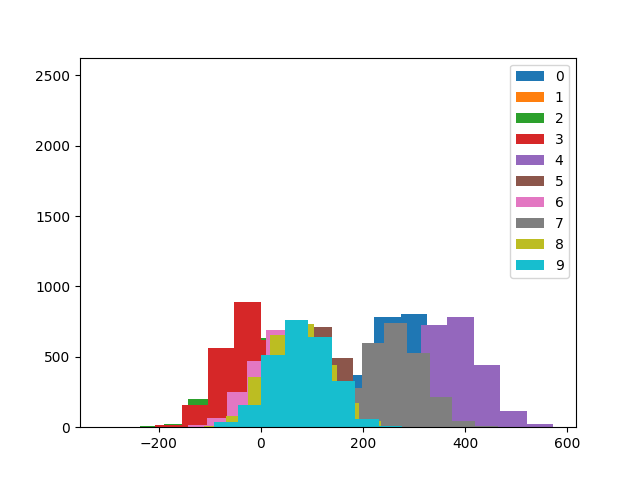

In [101]:
# check what means look like between reads
#data_dir = 'saturated_flats_UTR/'
DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260226/'
data_dir = 'utr_10reads/'
min,max = 100, 150 #100,150
inds     = np.s_[:,min:max,min:max]
ims,ims_notflat,reset = load_ims(DATA_FOLDER + data_dir, inds)

iread = 4
plt.figure()
plt.imshow(ims_notflat[1,0,:,:])

plt.figure()
plt.imshow(ims_notflat[6,iread,:,:] - ims_notflat[8,iread,:,:])

plt.figure()
for i in np.arange(10):
    diff = (ims_notflat[i,iread,:,:] - ims_notflat[i,0,:,:]) - (ims_notflat[1,iread,:,:] - ims_notflat[1,0,:,:])
    plt.hist(diff.flatten(),label=i)
    plt.legend()


